# 第068讲 经典方法比较项目

先约定任务与预算，再看模型。这里的全部输出由真实Python内核顺序执行。独立模拟质检数据不含个人信息。先修：第025至026、050至053讲及所比较方法的章节。

In [1]:
import numpy as np
from pathlib import Path
from IPython.display import display, Image
from common import load_data
from experiment import run, point_losses, paired_bootstrap
data = load_data()
print({name: len(part["id"]) for name, part in data.items()})

{'train': 450, 'validation': 225, 'test': 225}


## 手算先于大实验
正样本取p，负样本取1-p。先算每行负对数，再平均。

In [2]:
y = np.array([1, 0]); p = np.array([0.8, 0.3])
print("per-row loss:", point_losses(y,p))
print("mean log loss:", point_losses(y,p).mean())
print("Brier:", np.mean((p-y)**2))

per-row loss: [0.22314355 0.35667494]
mean log loss: 0.289909247626471
Brier: 0.06499999999999999


## 一次完整运行
select函数只接收训练和验证数据。三种候选各三个配置。测试在方案锁定后审计，不反向改变选择。

In [3]:
report = run()
for row in report["candidate_rows"]:
    print(row["name"], row["parameter"], round(row["validation_log_loss"],6))
print("locked winner:", report["winner"])

logistic_0 0.1 0.635715
logistic_1 1 0.636814
logistic_2 10 0.637008
forest_0 3 0.630827
forest_1 6 0.601119
forest_2 None 0.580677
knn_0 5 1.015321
knn_1 15 0.554036
knn_2 35 0.573727
locked winner: knn_1


In [4]:
for name, item in report["test"].items():
    m = item["metrics"]
    print(name, "logloss", round(m["log_loss"],6), "accuracy", round(m["accuracy"],6), "Wilson95", np.round(m["accuracy_wilson_95"],6))

prior logloss 0.679605 accuracy 0.582222 Wilson95 [0.516928 0.644756]
logistic logloss 0.639666 accuracy 0.608889 Wilson95 [0.543808 0.670314]
forest logloss 0.544137 accuracy 0.746667 Wilson95 [0.686025 0.799027]
knn logloss 0.560582 accuracy 0.684444 Wilson95 [0.621056 0.74164 ]


## 配对区间
差值是某方法减逻辑回归。相同索引同时取两个模型的损失；这里不重训模型，也不重复选参。

In [5]:
for name, value in report["paired_vs_logistic"].items():
    print(name, round(value["mean_delta"],6), np.round(value["percentile_95"],6))

prior 0.039939 [0.000417 0.080568]
forest -0.095529 [-0.125021 -0.066213]
knn -0.079084 [-0.120335 -0.038278]


## 校准与区分
低ECE并不保证好的AUC。空箱保留None，不能伪造为0%事件率。

In [6]:
for name, item in report["test"].items():
    print(name, "ECE", round(item["metrics"]["ece_5"],6), "AUC", item["metrics"]["roc_auc"])
print(report["test"]["knn"]["metrics"]["calibration"])

prior ECE 0.004444 AUC 0.5
logistic ECE 0.021949 AUC 0.6550267987656326
forest ECE 0.080327 AUC 0.8132207243787559
knn ECE 0.053037 AUC 0.7787883709598831
[{'bin': 0, 'n': 27, 'mean_probability': 0.10370370370370371, 'event_rate': 0.1111111111111111}, {'bin': 1, 'n': 64, 'mean_probability': 0.2666666666666666, 'event_rate': 0.203125}, {'bin': 2, 'n': 86, 'mean_probability': 0.4527131782945736, 'event_rate': 0.5232558139534884}, {'bin': 3, 'n': 42, 'mean_probability': 0.6587301587301587, 'event_rate': 0.6428571428571429}, {'bin': 4, 'n': 6, 'mean_probability': 0.8444444444444444, 'event_rate': 1.0}]


## 失败不是自动等同于坏数据
真概率只在合成数据中已知。对低概率事件的一次正标签不能直接判断模型或标注错误。

In [7]:
for item in report["test"]["knn"]["failures"][:3]:
    print(item)

{'id': 'case_0266', 'y': 1, 'p': 0.06666666666666667, 'p_true': 0.160580067796, 'log_loss': 2.70805020110221}
{'id': 'case_0318', 'y': 1, 'p': 0.13333333333333333, 'p_true': 0.165923343456, 'log_loss': 2.0149030205422647}
{'id': 'case_0748', 'y': 1, 'p': 0.13333333333333333, 'p_true': 0.472888178818, 'log_loss': 2.0149030205422647}


In [8]:
from plots import draw
names = draw(report, Path("outputs/notebook-figures"))
print("generated", len(names), "figures")

generated 7 figures


### 数据隔离

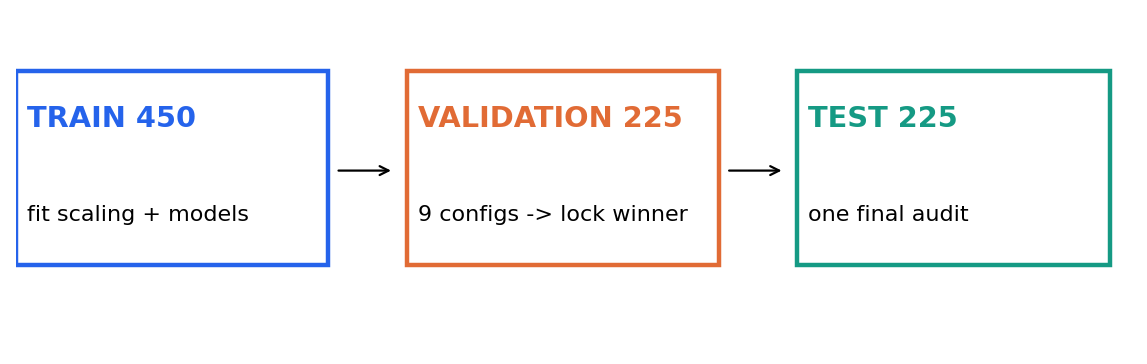

In [9]:
display(Image(filename="outputs/notebook-figures/01_protocol.png"))

### 全部搜索

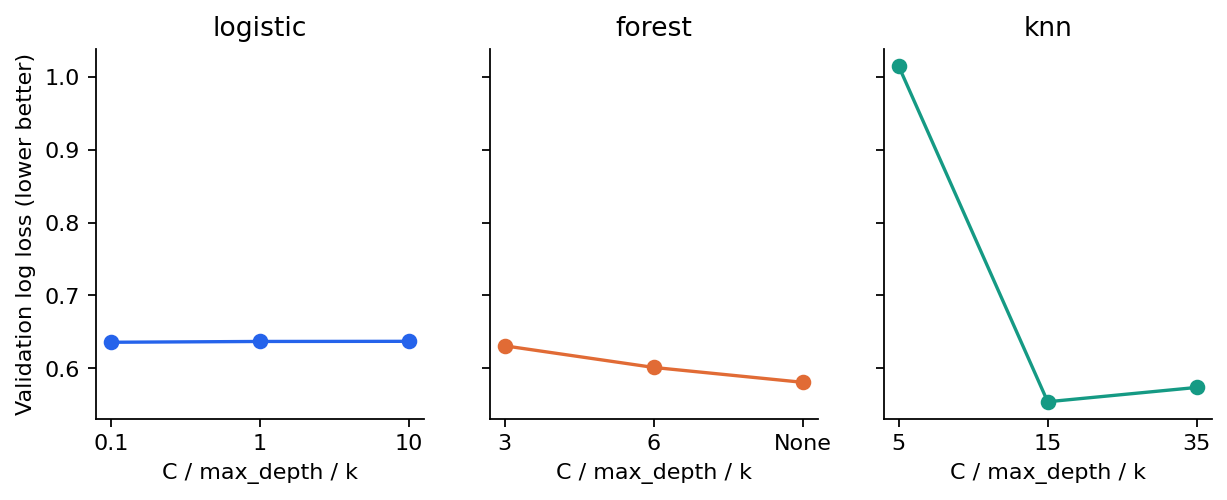

In [10]:
display(Image(filename="outputs/notebook-figures/02_fair_search.png"))

### 封存测试

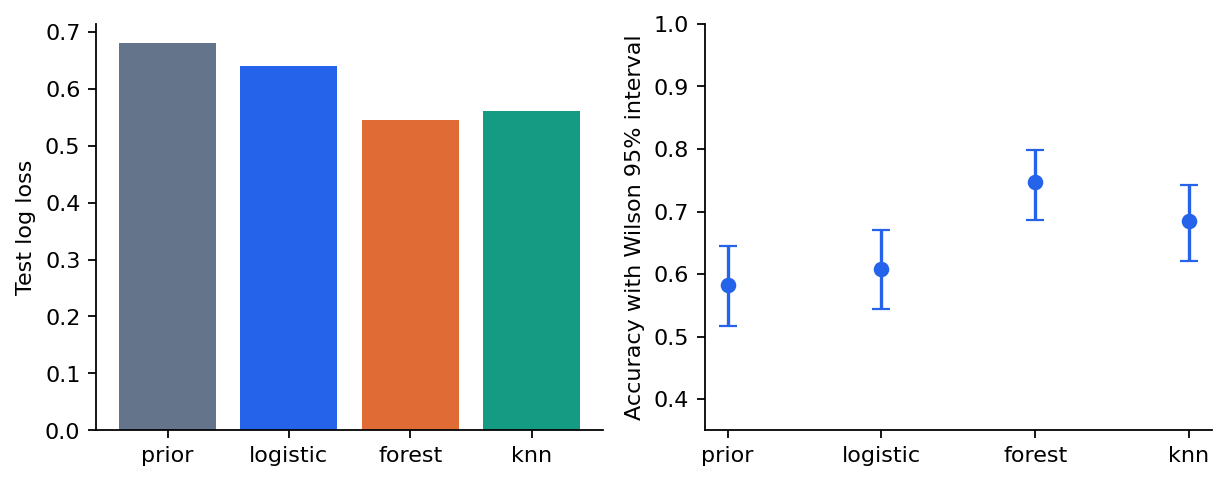

In [11]:
display(Image(filename="outputs/notebook-figures/03_heldout_metrics.png"))

### 可靠性图

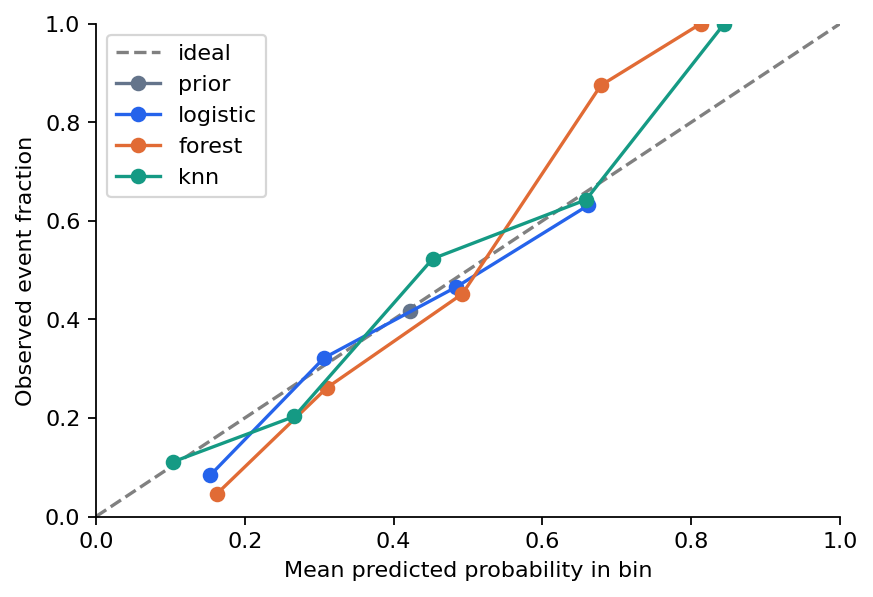

In [12]:
display(Image(filename="outputs/notebook-figures/04_calibration.png"))

### 配对区间

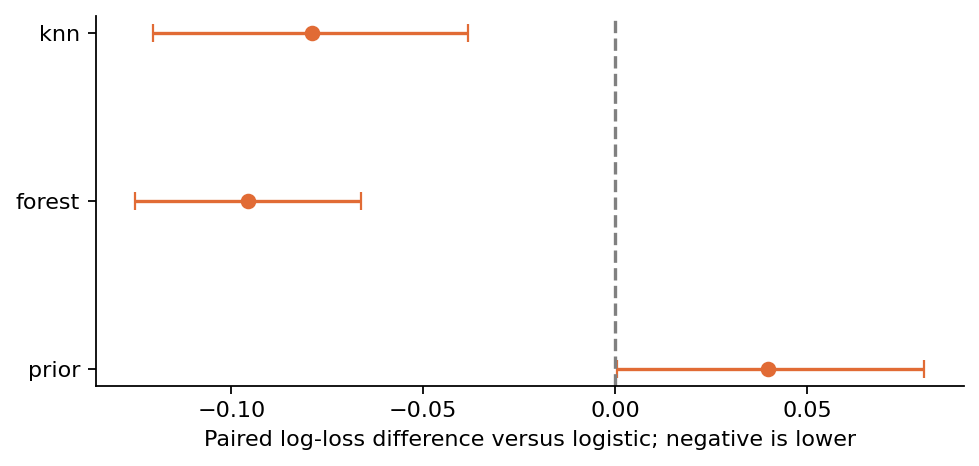

In [13]:
display(Image(filename="outputs/notebook-figures/05_paired_intervals.png"))

### 实测成本

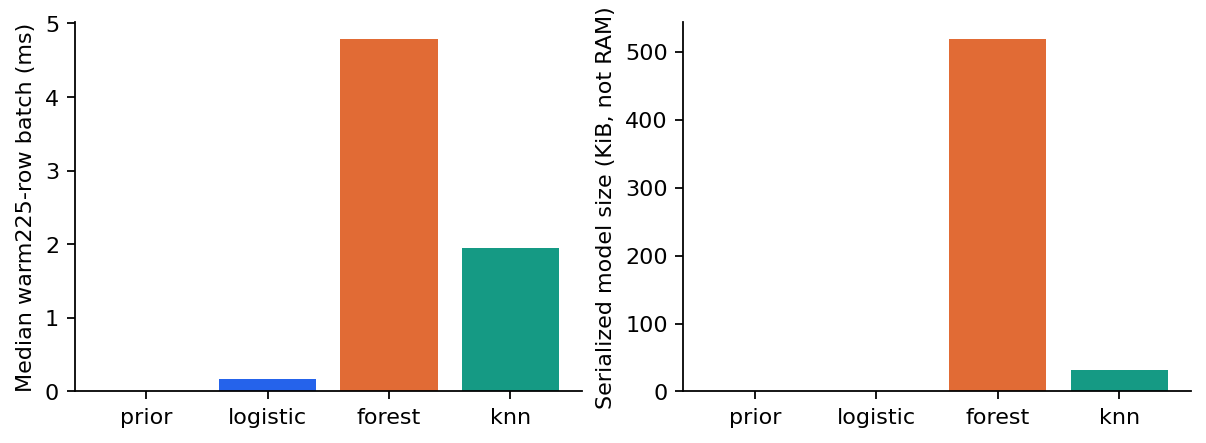

In [14]:
display(Image(filename="outputs/notebook-figures/06_costs.png"))

### 事前切片

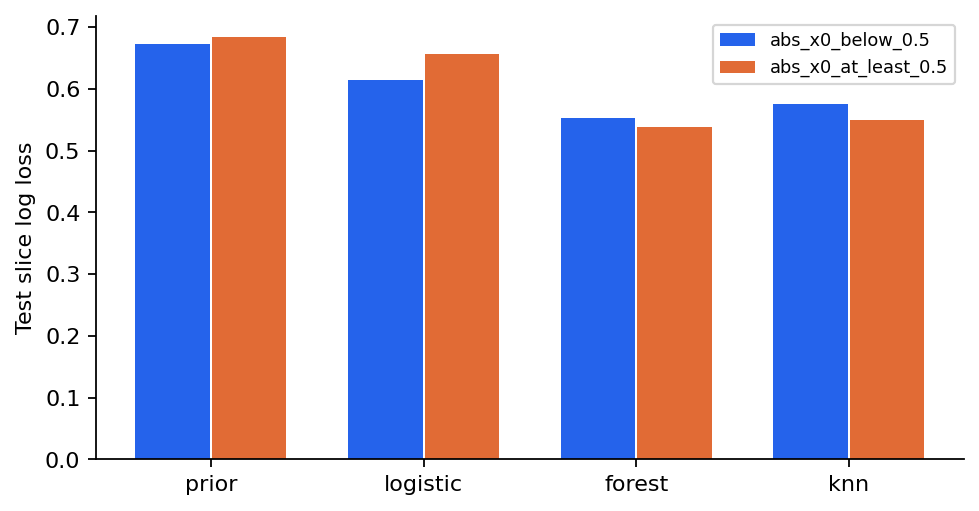

In [15]:
display(Image(filename="outputs/notebook-figures/07_failure_slices.png"))

## 实验结论
本次15近邻由验证集选中，但森林测试损失更低。保留选择记录是科学比较的一部分。区间不包括全流程选择不确定性，批预测耗时与序列化字节也不是目标设备的完整资源测量。